<a href="https://colab.research.google.com/github/alivarmazyar/Machine-learning/blob/main/Week_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (2520751, 53)
Classes: ['Bots' 'Brute Force' 'DDoS' 'DoS' 'Normal Traffic' 'Port Scanning'
 'Web Attacks']

========== Original Decision Tree ==========
Accuracy: 0.998349699692949

Classification Report:
                precision    recall  f1-score   support

          Bots       0.79      0.82      0.80       584
   Brute Force       1.00      1.00      1.00      2745
          DDoS       1.00      1.00      1.00     38404
           DoS       1.00      1.00      1.00     58124
Normal Traffic       1.00      1.00      1.00    628518
 Port Scanning       0.99      0.98      0.99     27208
   Web Attacks       0.99      0.96      0.98       643

      accuracy                           1.00    756226
     macro avg       0.97      0.97      0.97    756226
  weighted avg       1.00      1.00      1.00    756226



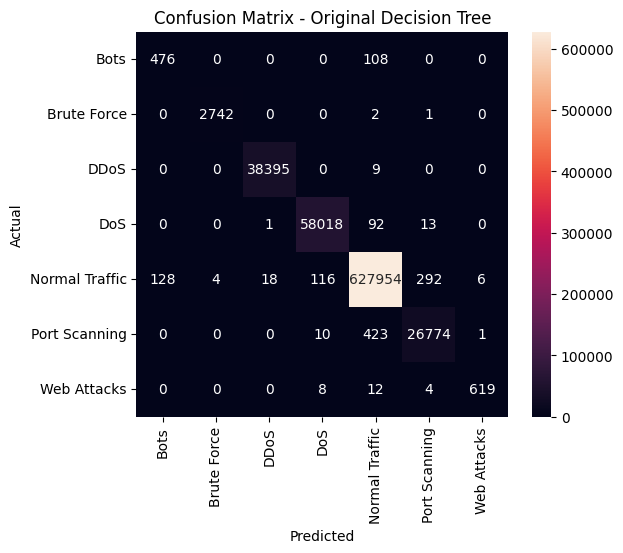


========== Improved Decision Tree ==========
Accuracy: 0.9859565791178827

Classification Report:
                precision    recall  f1-score   support

          Bots       0.11      0.99      0.20       584
   Brute Force       0.94      1.00      0.97      2745
          DDoS       1.00      1.00      1.00     38404
           DoS       0.95      0.99      0.97     58124
Normal Traffic       1.00      0.98      0.99    628518
 Port Scanning       0.99      1.00      0.99     27208
   Web Attacks       0.23      0.99      0.38       643

      accuracy                           0.99    756226
     macro avg       0.75      0.99      0.79    756226
  weighted avg       0.99      0.99      0.99    756226



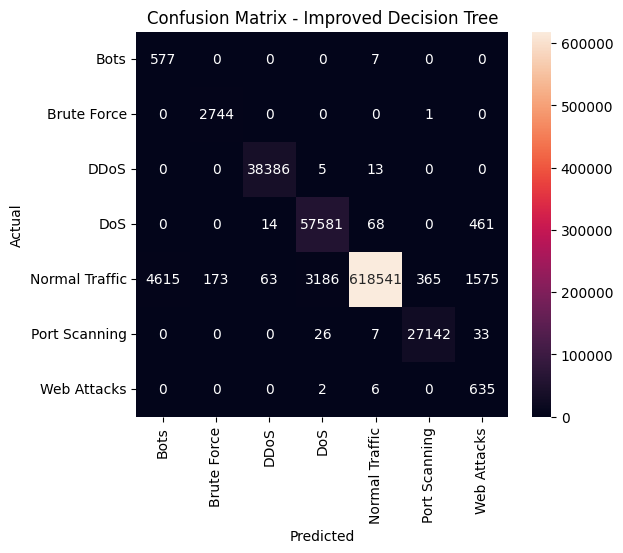


Model Comparison:
      Model  Accuracy
0  Original  0.998350
1  Improved  0.985957


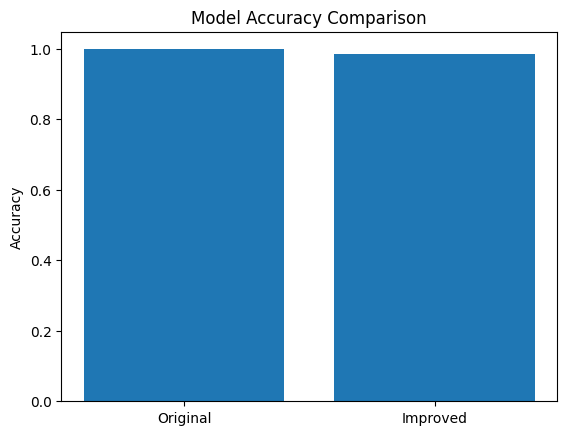

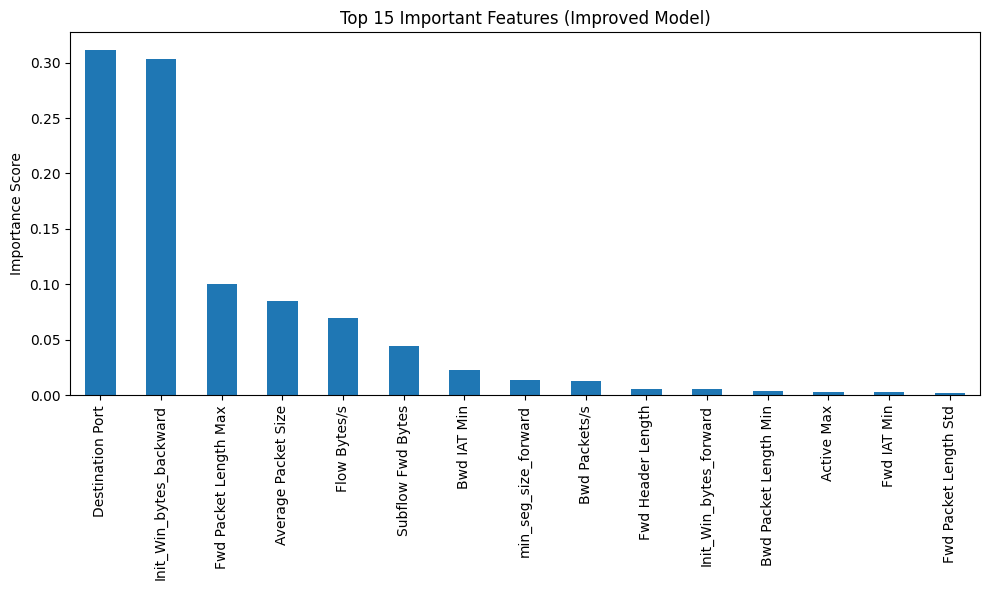

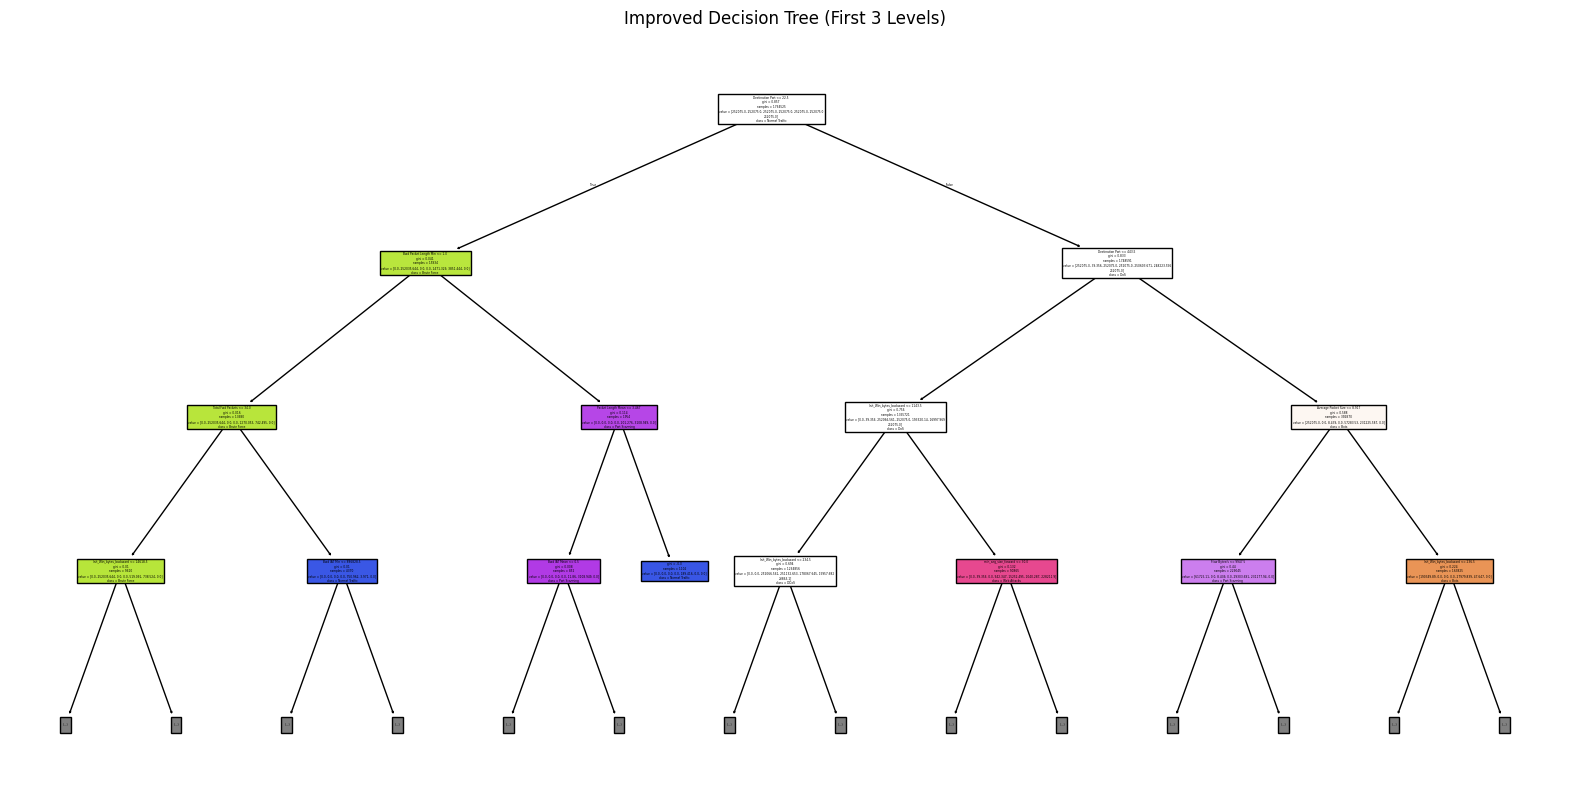

In [1]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder


#Load Dataset

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cicids2017_cleaned.csv")

print("Dataset Shape:", df.shape)


#Prepare Data

X = df.drop("Attack Type", axis=1)
y = df["Attack Type"]

# Encode target

le = LabelEncoder()
y = le.fit_transform(y)

print("Classes:", le.classes_)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


#MODEL 1 — ORIGINAL (Baseline)

dt_original = DecisionTreeClassifier(random_state=42)
dt_original.fit(X_train, y_train)

y_pred_original = dt_original.predict(X_test)


#MODEL 2 — IMPROVED

dt_improved = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42
)

dt_improved.fit(X_train, y_train)

y_pred_improved = dt_improved.predict(X_test)


#Evaluation Function

def evaluate_model(name, y_test, y_pred):
    print(f"\n========== {name} ==========")

    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc


#Evaluate Both Models

acc_original = evaluate_model("Original Decision Tree", y_test, y_pred_original)
acc_improved = evaluate_model("Improved Decision Tree", y_test, y_pred_improved)


#Accuracy Comparison

comparison = pd.DataFrame({
    "Model": ["Original", "Improved"],
    "Accuracy": [acc_original, acc_improved]
})

print("\nModel Comparison:")
print(comparison)

# Plot comparison
plt.figure()
plt.bar(comparison["Model"], comparison["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


#Feature Importance (Improved Model)

feature_importance = pd.Series(
    dt_improved.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.head(15).plot(kind="bar")
plt.title("Top 15 Important Features (Improved Model)")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()


#Tree Visualisation (Limited Depth)

plt.figure(figsize=(20,10))
plot_tree(
    dt_improved,
    feature_names=X.columns,
    class_names=le.classes_,
    filled=True,
    max_depth=3
)
plt.title("Improved Decision Tree (First 3 Levels)")
plt.show()


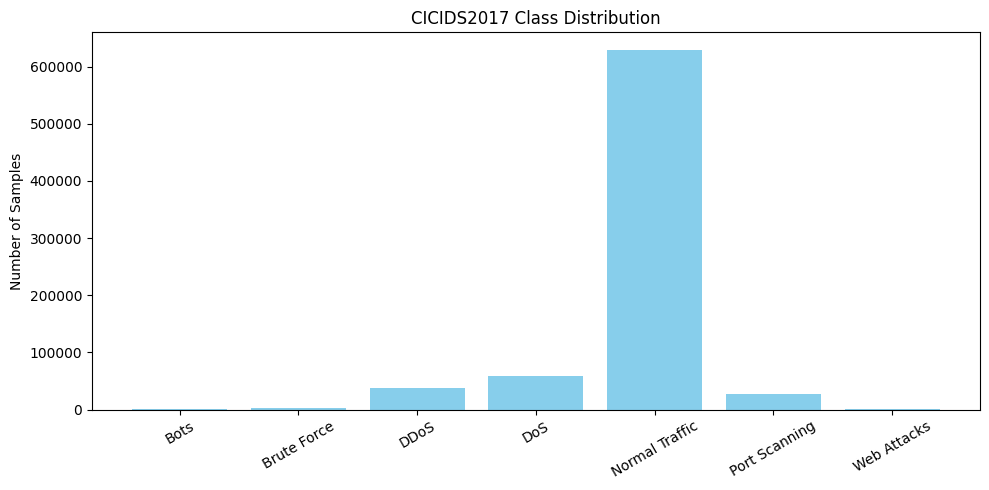

In [2]:
import matplotlib.pyplot as plt

# Class counts
classes = ["Bots", "Brute Force", "DDoS", "DoS", "Normal Traffic", "Port Scanning", "Web Attacks"]
counts = [584, 2745, 38404, 58124, 628518, 27208, 643]

# Plot
plt.figure(figsize=(10,5))
plt.bar(classes, counts, color='skyblue')
plt.title("CICIDS2017 Class Distribution")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

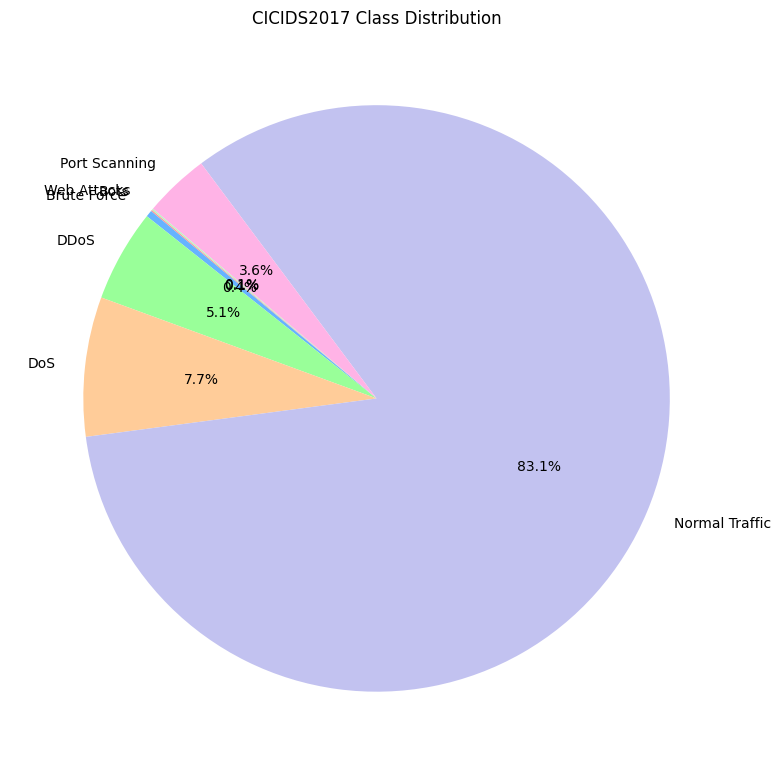

In [ ]:
import matplotlib.pyplot as plt

# Class counts
classes = ["Bots", "Brute Force", "DDoS", "DoS", "Normal Traffic", "Port Scanning", "Web Attacks"]
counts = [584, 2745, 38404, 58124, 628518, 27208, 643]

# Plot
plt.figure(figsize=(8,8))
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6','#c2f0c2']
plt.pie(counts, labels=classes, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title("CICIDS2017 Class Distribution")
plt.tight_layout()
plt.show()